# Experiment: Toy Projection Comparison

This notebook compares flow matching models trained on toy Gaussian to two moons data after fixed lifts from canonical 2d into higher-dimensional spaces.


## Training script

Run this from the repo root after `uv sync`:

```bash
bash scripts/train_toy_projection_comparison_grid.sh
```

Useful overrides:

```bash
SEED=0 EPOCHS=100 bash scripts/train_toy_projection_comparison_grid.sh 2 8 16 512
RFF_FEATURE_SCALE=1.0 LATENT_DIM=32 DISTANCE_WEIGHT=1.0 bash scripts/train_toy_projection_comparison_grid.sh 2 8 16 512
```


## Linear vs nonlinear lifts

- A `D x 2` column-orthonormal matrix defines a linear lift from `R^2` into a 2d linear subspace of `R^D`
- A linear subspace is a set closed under addition and scalar multiplication and it passes through the origin
- If you lift 2d data with a column-orthonormal matrix and then run PCA with 2 components in `R^D`, PCA should recover the same 2d geometry up to centering plus rotation or reflection
- In this pipeline the linear lifted data can be mapped exactly back to canonical 2d up to numerical error
- The nonlinear figure below uses a fixed residual random Fourier feature lift `x -> [x, phi(x)]` so it is not a column-orthonormal matrix projection


In [1]:
from pathlib import Path
import json

from hydra.utils import instantiate
import matplotlib.pyplot as plt
import numpy as np
import ot
import pandas as pd
from omegaconf import OmegaConf

from flatcfm.analysis import load_toy_prediction_adata

plt.rcParams["figure.dpi"] = 140


In [2]:
RUNS_ROOT = Path("artifacts/runs")
DIMS = [2, 8, 16, 512]

MODEL_SPECS = [
    {
        "lift_family": "linear_orthogonal",
        "model_label": "fm",
        "experiment_template": "toy_fm_lifted_d{dim}",
    },
    {
        "lift_family": "linear_orthogonal",
        "model_label": "fm + ot",
        "experiment_template": "toy_fm_lifted_ot_d{dim}",
    },
    {
        "lift_family": "linear_orthogonal",
        "model_label": "fm in pca",
        "experiment_template": "toy_fm_lifted_pca_d{dim}",
    },
    {
        "lift_family": "linear_orthogonal",
        "model_label": "fm in gr-ae latent",
        "experiment_template": "toy_fm_lifted_ae_latent_d{dim}",
    },
    {
        "lift_family": "nonlinear_rff",
        "model_label": "fm",
        "experiment_template": "toy_fm_nonlinear_rff_d{dim}",
    },
    {
        "lift_family": "nonlinear_rff",
        "model_label": "fm + ot",
        "experiment_template": "toy_fm_nonlinear_rff_ot_d{dim}",
    },
    {
        "lift_family": "nonlinear_rff",
        "model_label": "fm in pca",
        "experiment_template": "toy_fm_nonlinear_rff_pca_d{dim}",
    },
    {
        "lift_family": "nonlinear_rff",
        "model_label": "fm in gr-ae latent",
        "experiment_template": "toy_fm_nonlinear_rff_ae_latent_d{dim}",
    },
    {
        "lift_family": "linear_orthogonal",
        "model_label": "fm in mse-ae latent",
        "experiment_template": "toy_fm_lifted_ae_latent_mse_d{dim}",
    },
    {
        "lift_family": "nonlinear_rff",
        "model_label": "fm in mse-ae latent",
        "experiment_template": "toy_fm_nonlinear_rff_ae_latent_mse_d{dim}",
    },
]

PLOT_FAMILIES = {
    "linear_orthogonal": {
        "title": "Linear orthogonal lift back in canonical 2d",
        "rows": ["ground truth", "fm", "fm + ot", "fm in pca", "fm in gr-ae latent", "fm in mse-ae latent"],
    },
    "nonlinear_rff": {
        "title": "Nonlinear residual RFF lift back in canonical 2d",
        "rows": ["ground truth", "fm", "fm + ot", "fm in pca", "fm in gr-ae latent", "fm in mse-ae latent"],
    },
}

TARGET_COLORS = {1: "tab:green", 2: "tab:blue"}
PREDICTION_COLORS = {1: "tab:red", 2: "tab:orange"}

In [3]:
def latest_run_dir(experiment_name: str) -> Path:
    run_root = RUNS_ROOT / experiment_name
    run_dirs = sorted(path for path in run_root.glob("*") if path.is_dir())
    if not run_dirs:
        raise FileNotFoundError(f"No runs found under {run_root}")
    return run_dirs[-1]


def instantiate_datamodule(cfg):
    return instantiate(
        cfg.data,
        data=OmegaConf.to_container(cfg.data, resolve=True),
        splitter=OmegaConf.to_container(cfg.splitter, resolve=True),
        space=OmegaConf.to_container(cfg.space, resolve=True),
        evaluation_space=OmegaConf.to_container(cfg.evaluation_space, resolve=True),
        condition=OmegaConf.to_container(cfg.condition, resolve=True),
        paths=OmegaConf.to_container(cfg.paths, resolve=True),
        ae_geometry=OmegaConf.to_container(cfg.ae_geometry, resolve=True),
        task=OmegaConf.to_container(cfg.task, resolve=True),
        predict=OmegaConf.to_container(cfg.predict, resolve=True),
        trainer=OmegaConf.to_container(cfg.trainer, resolve=True),
        _recursive_=False,
    )


def load_run_bundle(experiment_name: str) -> dict:
    run_dir = latest_run_dir(experiment_name)
    cfg = OmegaConf.load(run_dir / "run_config.yaml")
    history = json.loads((run_dir / "history.json").read_text())
    pred_adata = load_toy_prediction_adata(run_dir)

    dm = instantiate_datamodule(cfg)
    dm.setup("predict")
    full_adata = dm.adata_full
    obs = full_adata.obs
    control_mask = obs[dm.schema.control_column].to_numpy() == dm.schema.control_value
    _, val_mask = dm._build_train_val_masks()
    val_mask = np.asarray(val_mask, dtype=bool)
    target_mask = val_mask & ~np.asarray(control_mask, dtype=bool)

    targets = {}
    preds = {}
    for pert in [1.0, 2.0]:
        target_idx = target_mask & (obs[dm.schema.perturbation_source].astype(float).to_numpy() == pert)
        pred_idx = pred_adata.obs[dm.schema.perturbation_source].astype(float).to_numpy() == pert
        targets[int(pert)] = np.asarray(full_adata[target_idx].X, dtype=np.float32)
        preds[int(pert)] = np.asarray(pred_adata[pred_idx].X, dtype=np.float32)

    return {
        "run_dir": run_dir,
        "cfg": cfg,
        "history": history,
        "control": np.asarray(full_adata[control_mask].X, dtype=np.float32),
        "targets": targets,
        "preds": preds,
    }


def w2_squared(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if x.shape[0] == 0 or y.shape[0] == 0:
        return float("nan")
    a = np.full(x.shape[0], 1.0 / x.shape[0], dtype=np.float64)
    b = np.full(y.shape[0], 1.0 / y.shape[0], dtype=np.float64)
    cost = ot.dist(x, y, metric="sqeuclidean")
    return float(ot.emd2(a, b, cost))


def mean_w2_squared(bundle: dict) -> float:
    scores = []
    for pert in [1, 2]:
        scores.append(w2_squared(bundle["preds"][pert], bundle["targets"][pert]))
    return float(np.mean(scores))


def collect_run_registry(model_specs: list[dict], dims: list[int]) -> tuple[dict, pd.DataFrame]:
    registry = {}
    records = []
    for spec in model_specs:
        key = (spec["lift_family"], spec["model_label"])
        registry[key] = {}
        for dim in dims:
            experiment_name = spec["experiment_template"].format(dim=dim)
            bundle = load_run_bundle(experiment_name)
            registry[key][dim] = bundle
            records.append(
                {
                    "lift_family": spec["lift_family"],
                    "model_label": spec["model_label"],
                    "dim": dim,
                    "experiment_name": experiment_name,
                    "run_dir": str(bundle["run_dir"]),
                    "best_val": min(bundle["history"].get("val_loss", [np.nan]) or [np.nan]),
                    "mean_w2_squared_2d": mean_w2_squared(bundle),
                }
            )
    return registry, pd.DataFrame.from_records(records)


def family_specs(model_specs: list[dict], lift_family: str) -> list[dict]:
    return [spec for spec in model_specs if spec["lift_family"] == lift_family]


def plot_metric_summary(results: pd.DataFrame, lift_family: str) -> None:
    family_results = results[results["lift_family"] == lift_family].copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for model_label, frame in family_results.groupby("model_label"):
        ordered = frame.sort_values("dim")
        axes[0].plot(ordered["dim"], ordered["best_val"], marker="o", label=model_label)
        axes[1].plot(ordered["dim"], ordered["mean_w2_squared_2d"], marker="o", label=model_label)

    axes[0].set_xlabel("ambient dimension")
    axes[0].set_ylabel("best val loss in training space")
    axes[0].set_title(f"Validation loss for {lift_family} ↓")
    axes[0].set_xscale("log", base=2)
    axes[0].legend()

    axes[1].set_xlabel("ambient dimension")
    axes[1].set_ylabel("mean W2^2 in canonical 2d ↓")
    axes[1].set_title(f"Held-out prediction quality for {lift_family} ↓")
    axes[1].set_xscale("log", base=2)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_family_grid(run_registry: dict, model_specs: list[dict], lift_family: str, dims: list[int]) -> None:
    family_model_specs = family_specs(model_specs, lift_family)
    row_names = PLOT_FAMILIES[lift_family]["rows"]
    reference_label = family_model_specs[0]["model_label"]
    fig, axes = plt.subplots(
        len(row_names),
        len(dims),
        figsize=(4 * len(dims), 4 * len(row_names)),
        sharex=True,
        sharey=True,
    )
    axes = np.asarray(axes, dtype=object)
    if axes.ndim == 1:
        axes = axes[None, :]

    for col, dim in enumerate(dims):
        base_bundle = run_registry[(lift_family, reference_label)][dim]
        for row_idx, row_name in enumerate(row_names):
            ax = axes[row_idx, col]
            ax.scatter(base_bundle["control"][:, 0], base_bundle["control"][:, 1], color="lightgray", alpha=0.25, s=10)
            for pert, color in TARGET_COLORS.items():
                ax.scatter(
                    base_bundle["targets"][pert][:, 0],
                    base_bundle["targets"][pert][:, 1],
                    color=color,
                    alpha=0.25,
                    s=10,
                )

            if row_name != "ground truth":
                bundle = run_registry[(lift_family, row_name)][dim]
                for pert, color in PREDICTION_COLORS.items():
                    ax.scatter(bundle["preds"][pert][:, 0], bundle["preds"][pert][:, 1], color=color, alpha=0.55, s=10)

            if row_idx == 0:
                ax.set_title(f"D = {dim}")
            if col == 0:
                ax.set_ylabel(row_name)
            ax.set_xlim(-2, 2.5)
            ax.set_ylim(-2, 2)
            ax.set_box_aspect(1)

    plt.suptitle(PLOT_FAMILIES[lift_family]["title"], y=1.02)
    plt.tight_layout()
    plt.show()

In [4]:
run_registry, results = collect_run_registry(MODEL_SPECS, DIMS)
results = results.sort_values(["lift_family", "model_label", "dim"]).reset_index(drop=True)
results


,lift_family,model_label,dim,experiment_name,run_dir,best_val,mean_w2_squared_2d
0,linear_orthogonal,fm,2,toy_fm_lifted_d2,artifacts/runs/toy_fm_lifted_d2/20260322_224951,0.316764,0.062308
1,linear_orthogonal,fm,8,toy_fm_lifted_d8,artifacts/runs/toy_fm_lifted_d8/20260322_225540,0.083339,0.035902
2,linear_orthogonal,fm,16,toy_fm_lifted_d16,artifacts/runs/toy_fm_lifted_d16/20260322_230134,0.042511,0.023833
3,linear_orthogonal,fm,512,toy_fm_lifted_d512,artifacts/runs/toy_fm_lifted_d512/20260322_230736,0.001406,0.114322
4,linear_orthogonal,fm + ot,2,toy_fm_lifted_ot_d2,artifacts/runs/toy_fm_lifted_ot_d2/20260322_22...,0.424760,0.027316
5,linear_orthogonal,fm + ot,8,toy_fm_lifted_ot_d8,artifacts/runs/toy_fm_lifted_ot_d8/20260322_22...,0.110031,0.049237
6,linear_orthogonal,fm + ot,16,toy_fm_lifted_ot_d16,artifacts/runs/toy_fm_lifted_ot_d16/20260322_2...,0.055062,0.058228
7,linear_orthogonal,fm + ot,512,toy_fm_lifted_ot_d512,artifacts/runs/toy_fm_lifted_ot_d512/20260322_...,0.001766,0.140971
8,linear_orthogonal,fm in gr-ae latent,2,toy_fm_lifted_ae_latent_d2,artifacts/runs/toy_fm_lifted_ae_latent_d2/2026...,0.022163,0.053540
9,linear_orthogonal,fm in gr-ae latent,8,toy_fm_lifted_ae_latent_d8,artifacts/runs/toy_fm_lifted_ae_latent_d8/2026...,0.020940,0.060505


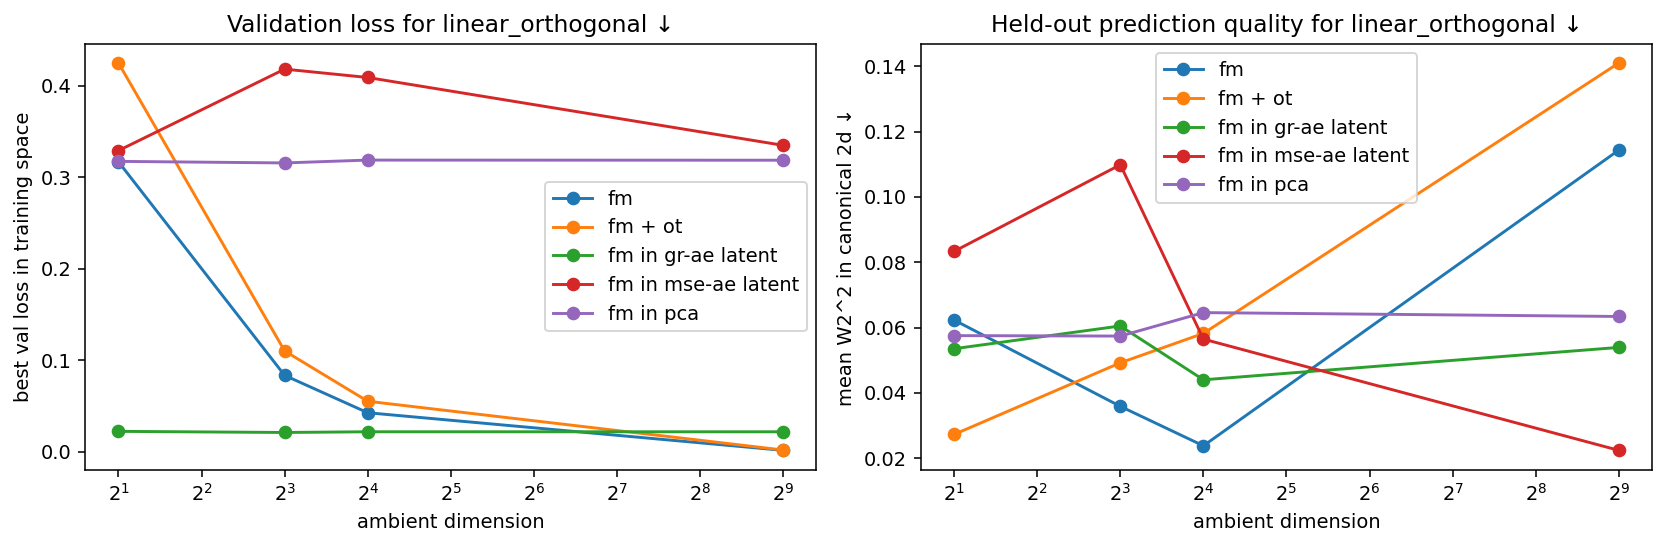

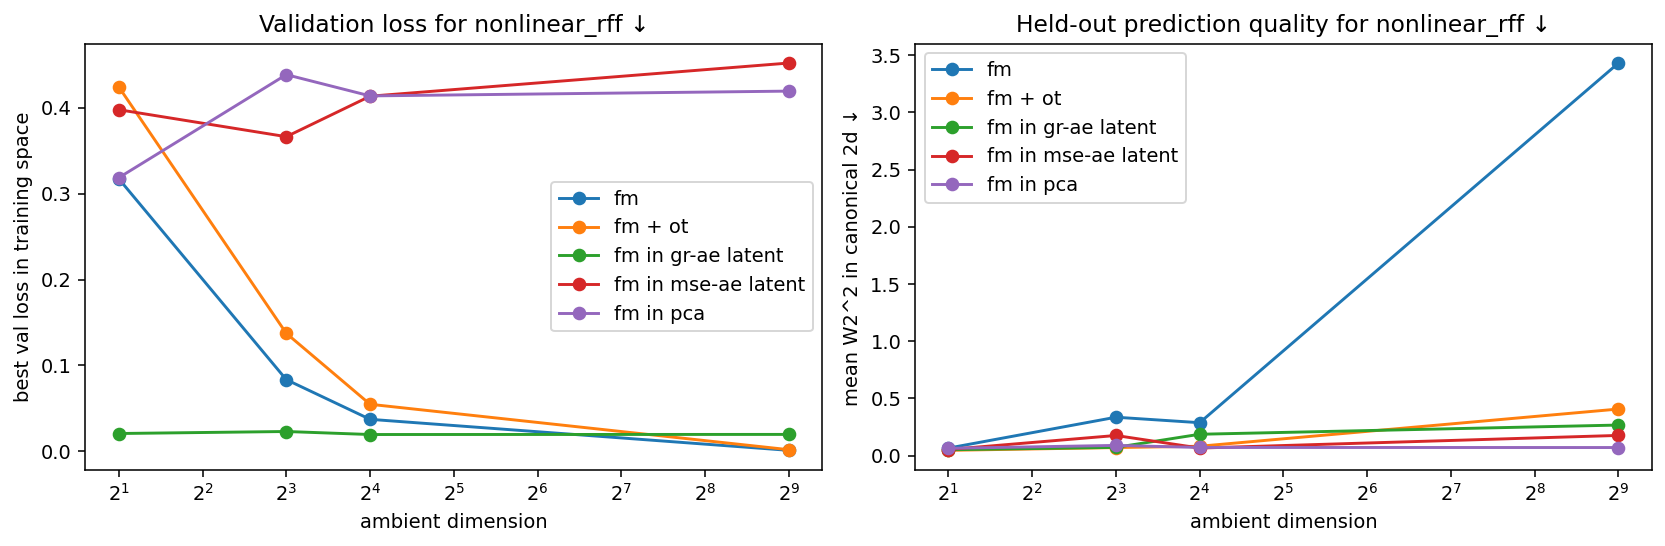

In [5]:
plot_metric_summary(results, "linear_orthogonal")
plot_metric_summary(results, "nonlinear_rff")


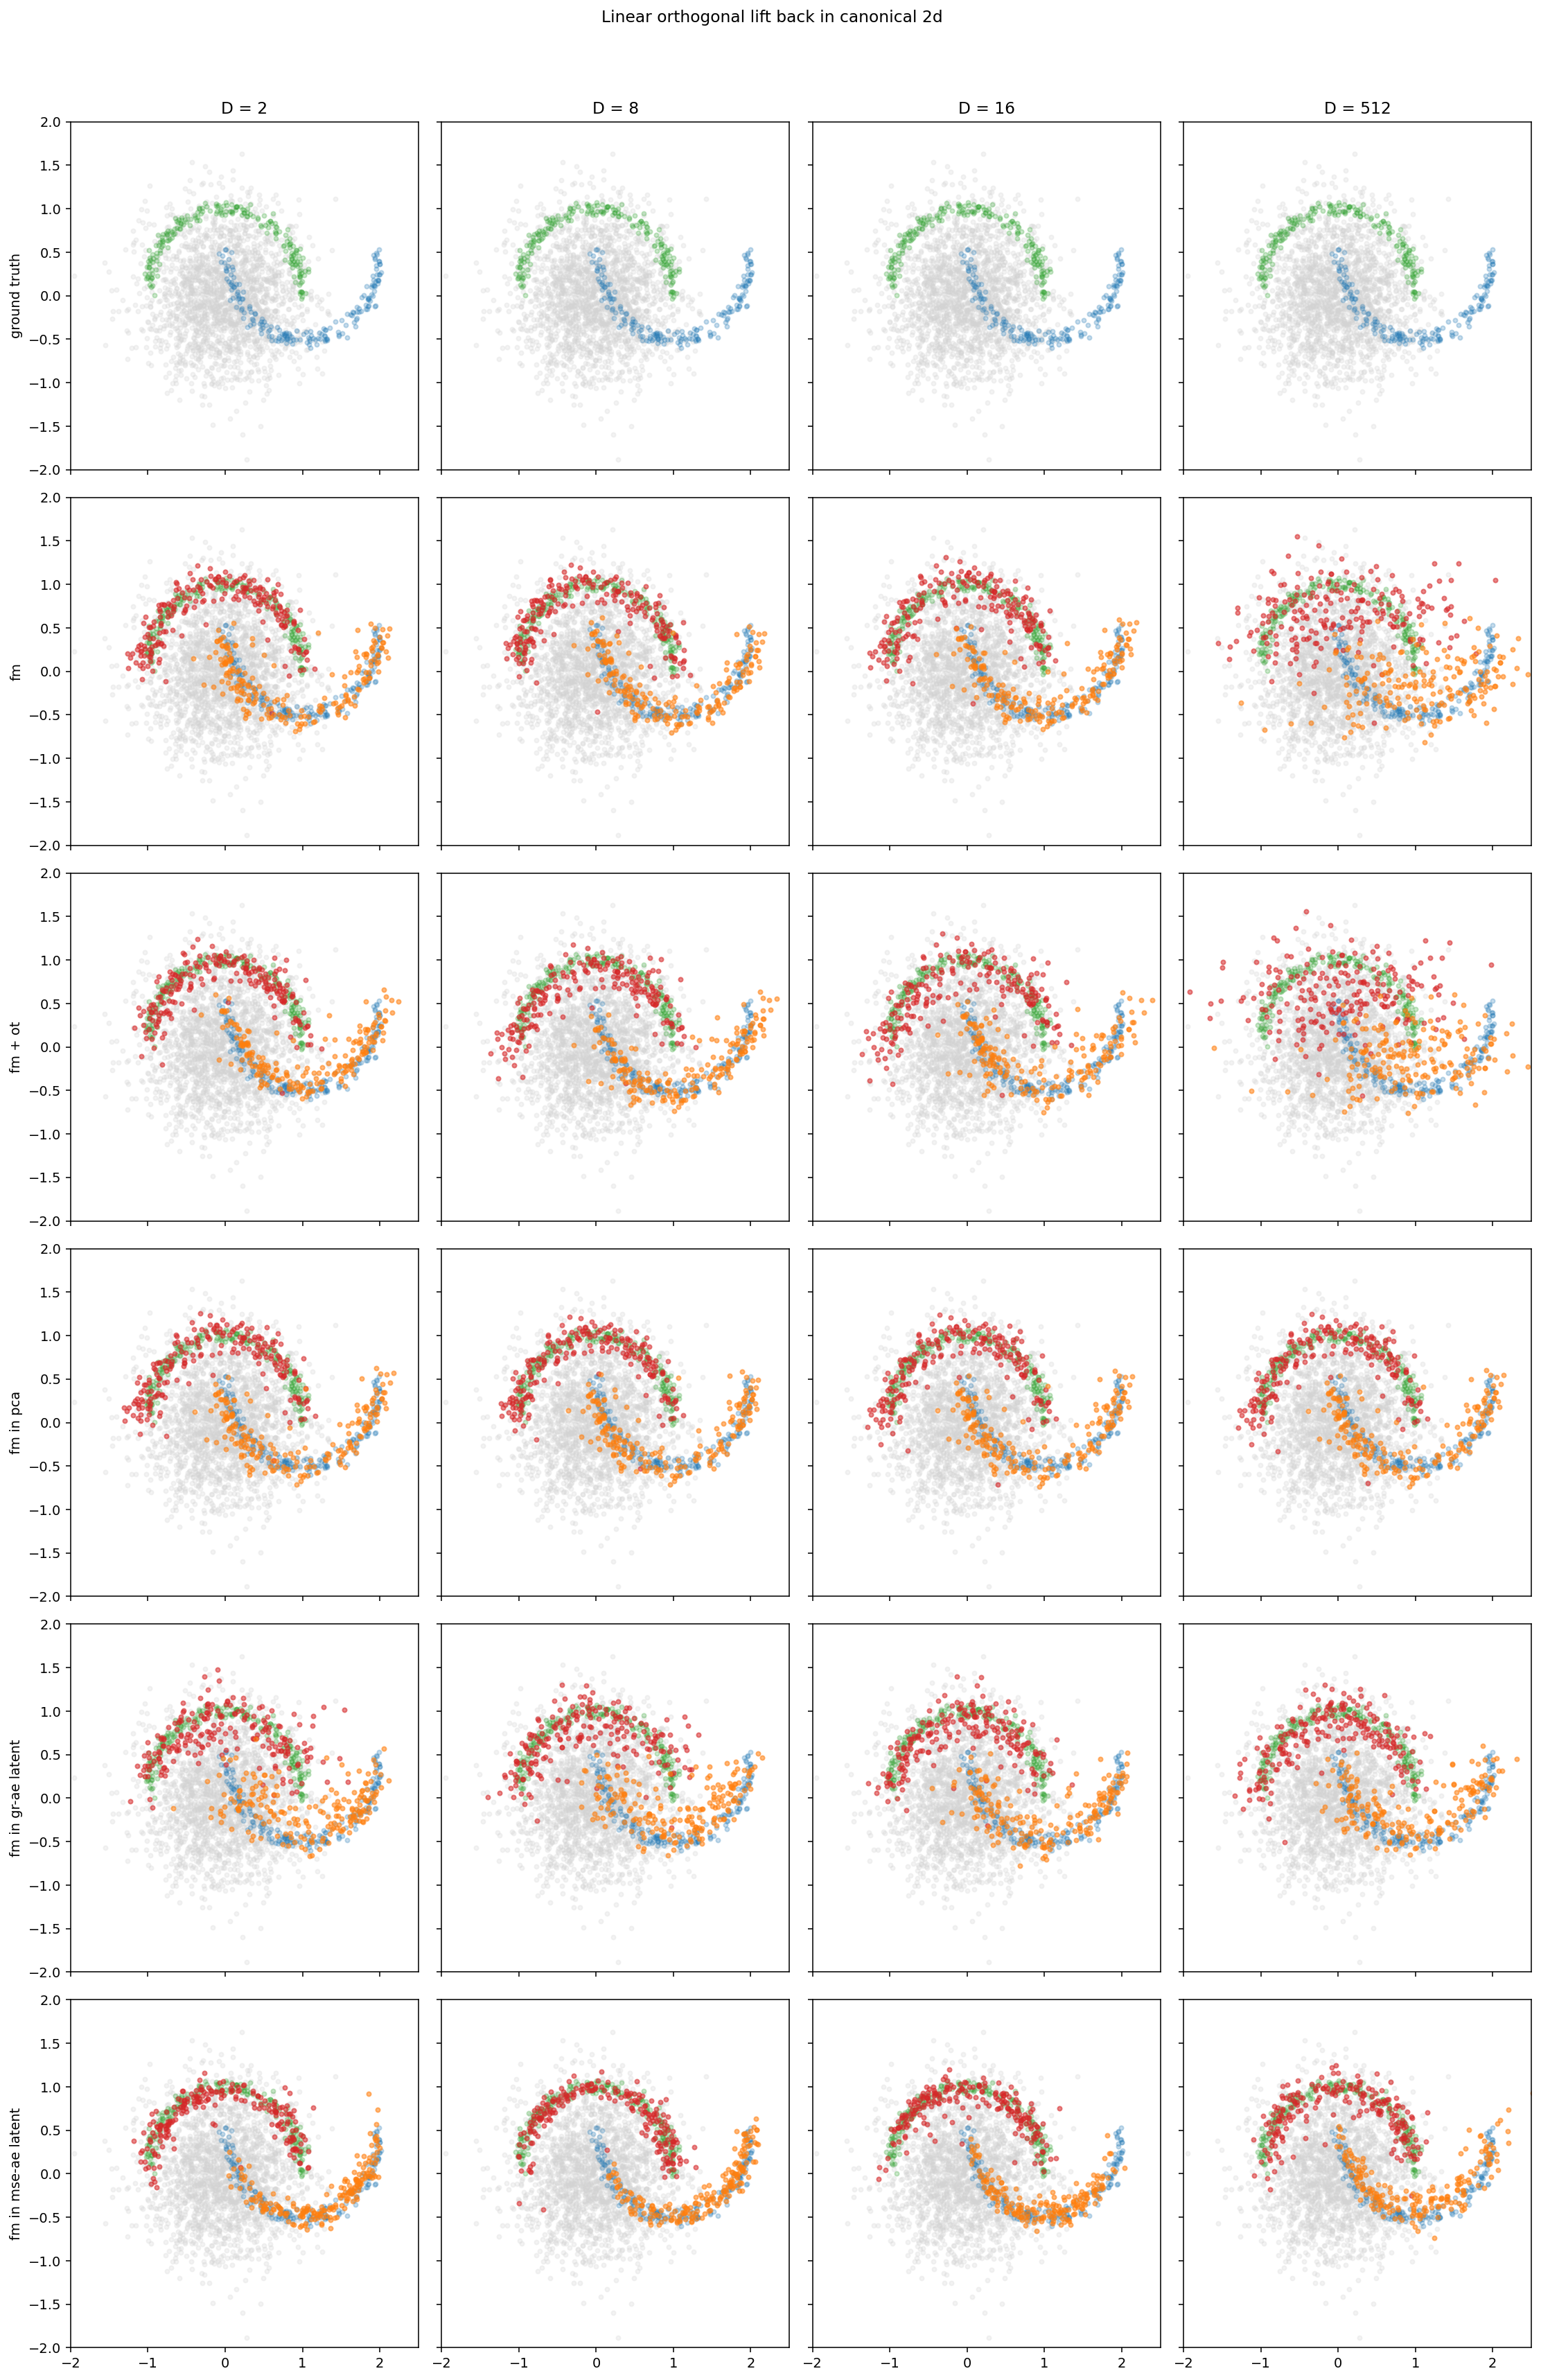

In [6]:
plot_family_grid(run_registry, MODEL_SPECS, "linear_orthogonal", DIMS)


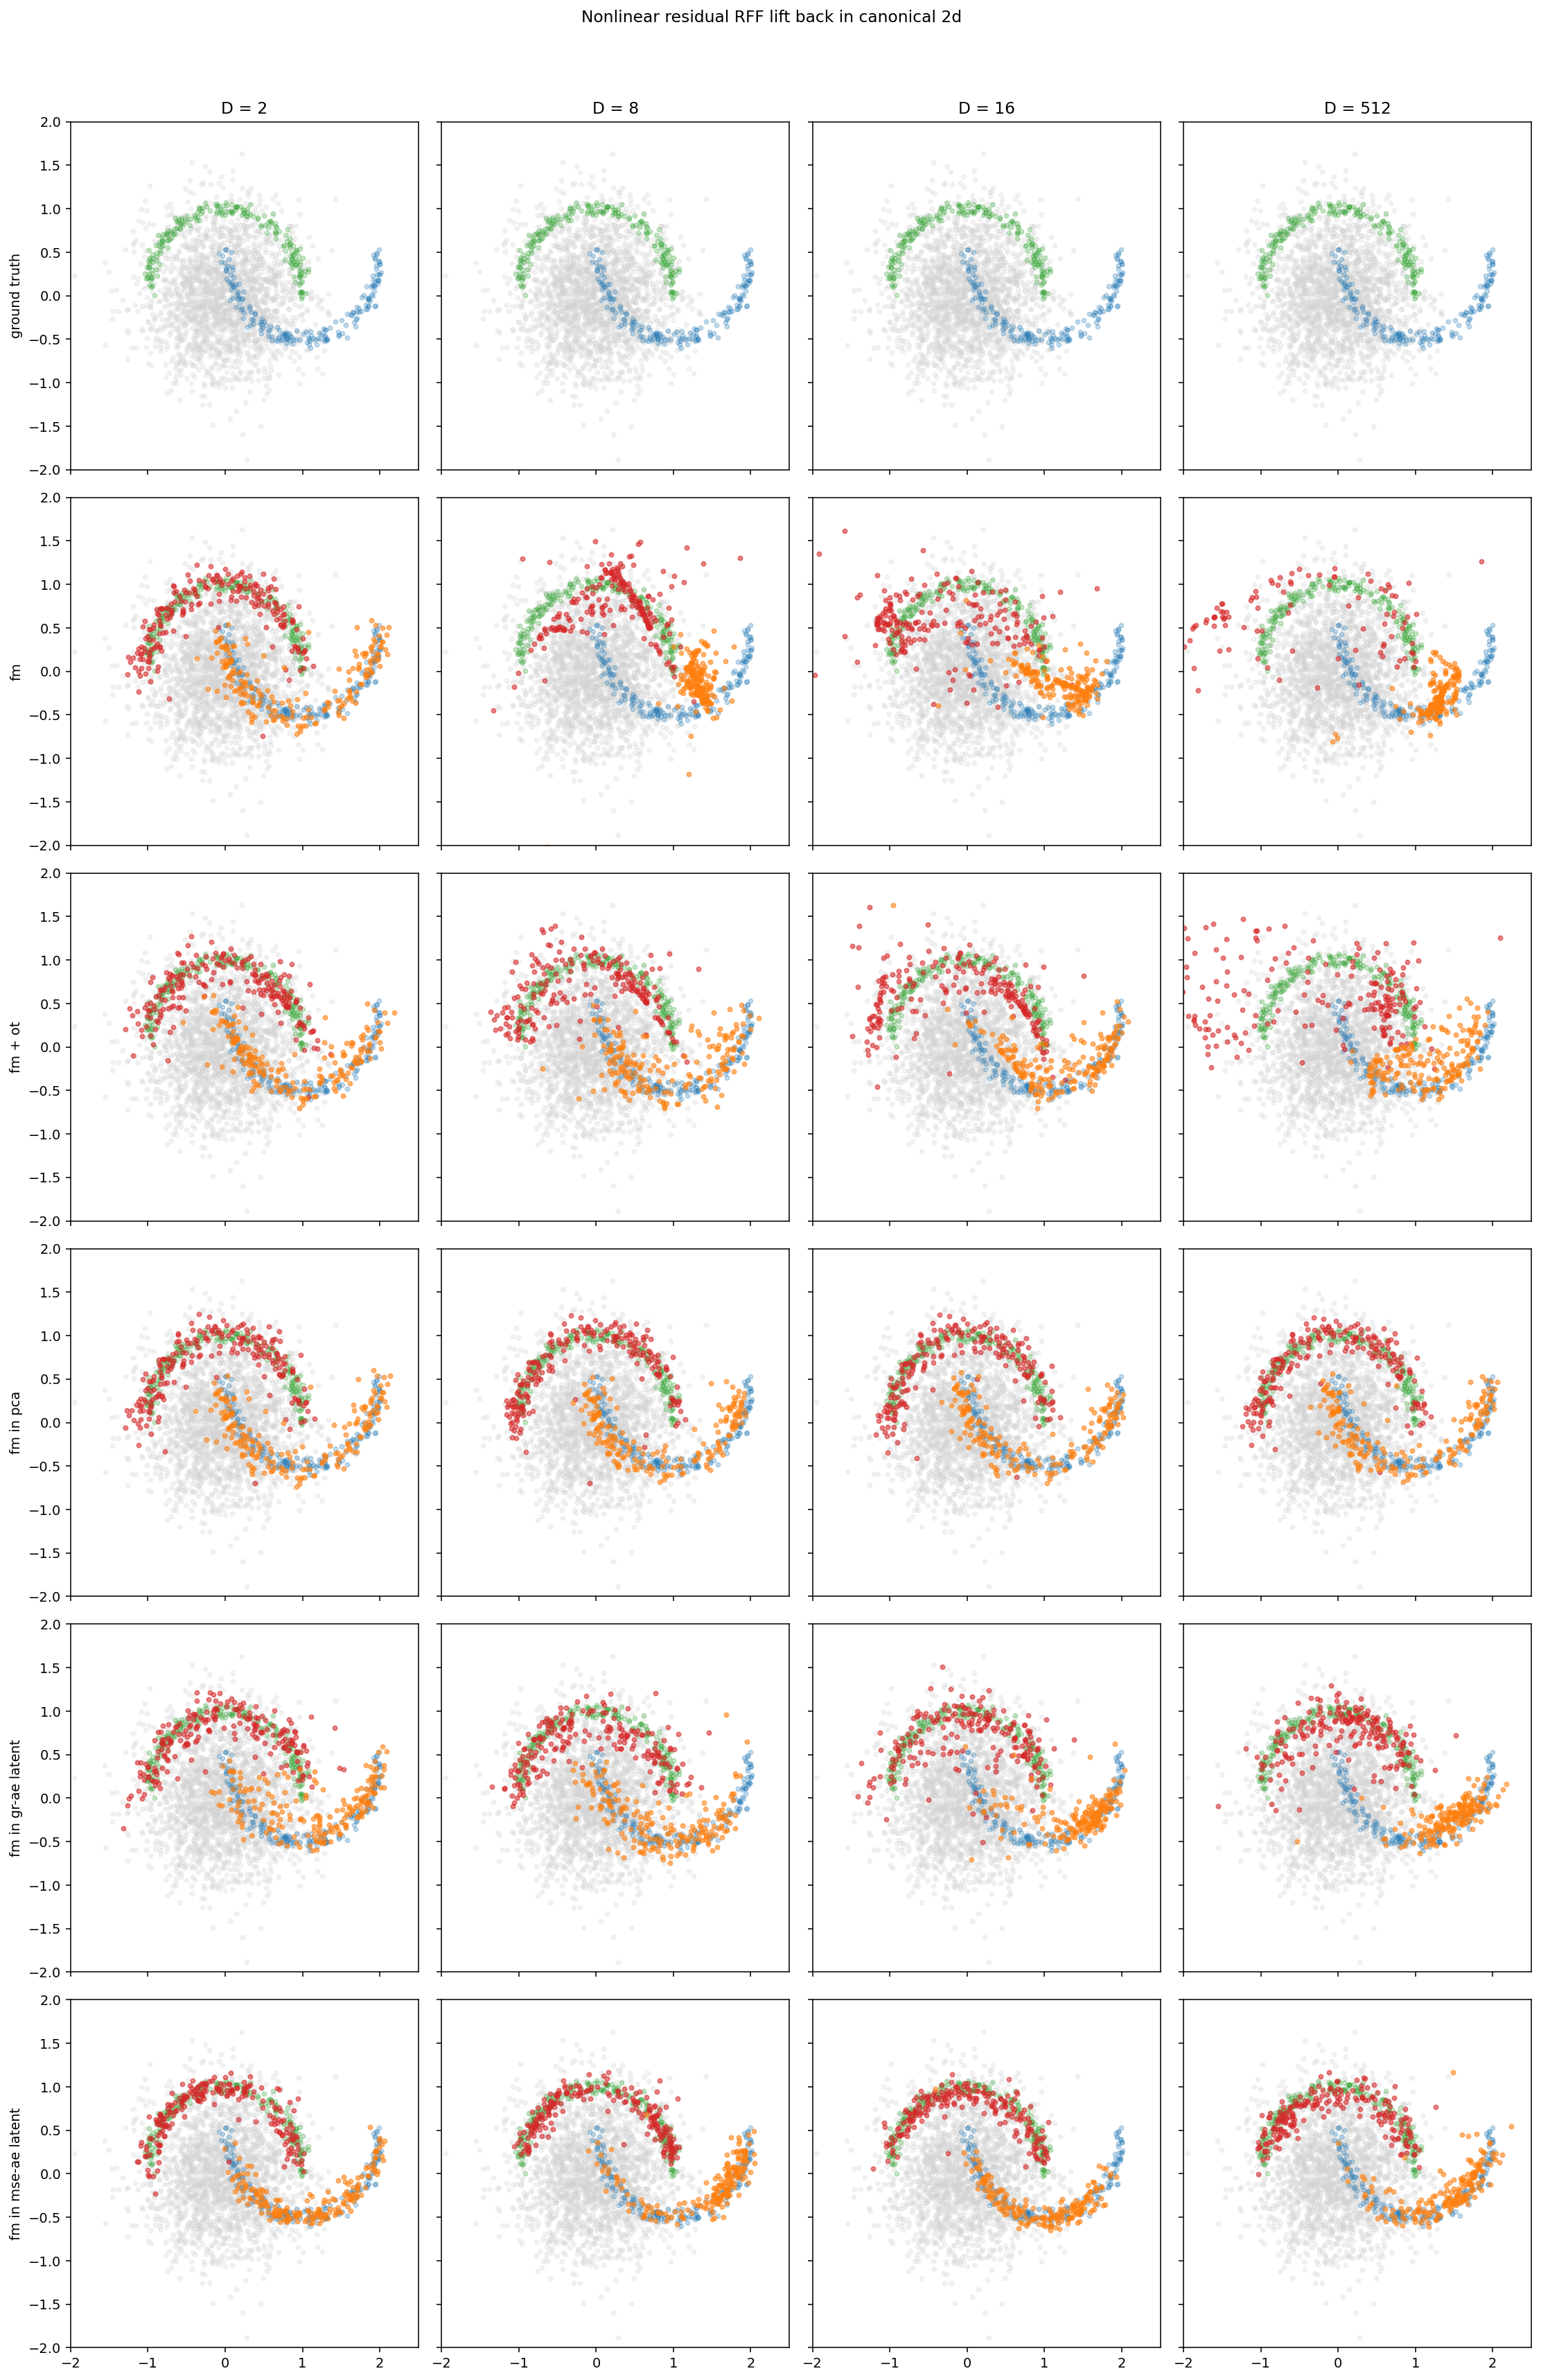

In [7]:
plot_family_grid(run_registry, MODEL_SPECS, "nonlinear_rff", DIMS)


## Extending this notebook

- To add a new model row, append one entry to `MODEL_SPECS`
- To compare a new lift family, add entries to `MODEL_SPECS` and `PLOT_FAMILIES`
- To change the ambient dimensions, edit `DIMS`
- Mean-flow can be added later by training matching toy runs and registering their experiment templates here
